## Exercises classifiers and evaluation

These exercises follow the general setup of [this tutorial in the R language](https://compgenomr.github.io/book/model-tuning-and-avoiding-overfitting.html).

In this exercise session you will go through some concepts related to classifiers and evaluation in Python. Parts of the code are already implemented, you need to fill in the remaining parts.

Your code should produce figures similar to the ones in the tutorial, but because the data you use is different, you will not get the same values.

If you want to see whether you get the same plots for the tutorial's data, check earlier chapters of the tutorial.

## Get example data

You can either use the example labels and features in the exercises repository, or if you already implemented some features, do the exercise with your own data.

In [ ]:
# Packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use your own features and labels or grab the csv files with features and labels from today's exercise.

# Load features and labels into dataframes
file_data = # File path to labels
file_features = # File path to feautures

df = pd.read_csv(file_data)
features = pd.read_csv(file_features)

# Check what's inside
print(df.head())

# Put everything we need together
df = df.drop(['image_id','seborrheic_keratosis'],axis=1)
df['area'] = features['area']
df['perimeter'] = features['perimeter']

# Please remember that area and perimeter alone are often not sufficient for classification.
# When doing your project, you will need other features.

print(df.head())

'rm' is not recognized as an internal or external command,
operable program or batch file.


       image_id  melanoma  seborrheic_keratosis
0  ISIC_0001769       0.0                   0.0
1  ISIC_0001852       0.0                   0.0
2  ISIC_0001871       0.0                   0.0
3  ISIC_0003462       0.0                   0.0
4  ISIC_0003539       0.0                   0.0
   melanoma      area  perimeter
0       0.0  216160.0     2013.0
1       0.0  130493.0     1372.0
2       0.0  205116.0     1720.0
3       0.0  161705.0     1344.0
4       0.0  317040.0     2063.0


fatal: destination path 'ProjectInDataScience2026_Exercises' already exists and is not an empty directory.


## Data splits

Example of splitting the data to create three subsets for training, validtion, and testing.

For reducing computation, you may want to reduce the size of the selected data using train_size and test_size parameters of the splitting functions. However, reducing the size of the dataset will lead to more variability of your results

After splitting, we want to normalize the features. Add your code for this below.

Read about scaling here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

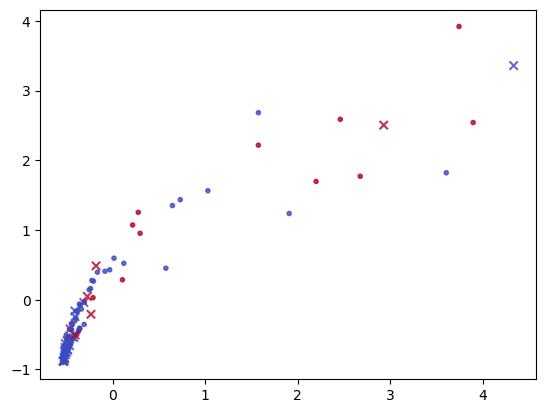

In [ ]:
# Prepare development (train and validation) and test splits
from sklearn.model_selection import train_test_split

x = df[['area','perimeter']]
y = df[['melanoma']]

dev_x, test_x, dev_y, test_y = train_test_split(
        x, y, stratify=y, random_state=0)

train_x, val_x, train_y, val_y = train_test_split(
        dev_x, dev_y, stratify=dev_y)


## TODO - YOUR CODE HERE
# After reading about scalers, ask yourself, what should we fit it on? Train, validation, test, or all of them together? Why, what are the pros and cons of each choice? 


## Train and evaluate a classifier

Here is an example of using a k-NN classifier, starting with k=1, and evaluating the trained classifier with AUC.

Examine the performances on the training and validation set, is this what you expect? What do you expect if you change the k parameter?

Create a for loop where you try different values of k, and plot both the training and validation AUCs. Since this is real data, the plots will not be as smooth as the theoretical example in the lecture. What value of k do you find appropriate?


1.0
0.6347826086956521


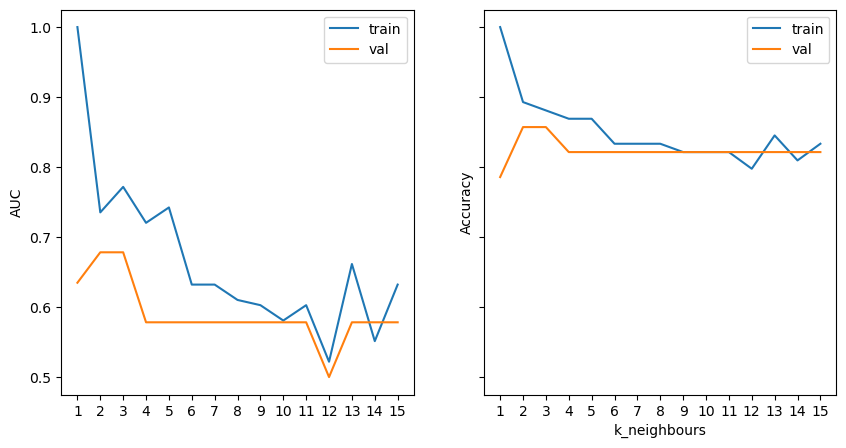

In [ ]:
#Import classifier and metric
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score


# Training
knn1 = KNeighborsClassifier(n_neighbors=1) # other hyperparameters possible
knn1_trained = knn1.fit(train_x, np.ravel(train_y))

# Prediction on the training set, evaluate with AUC
train_pred_knn1 = knn1_trained.predict(train_x)
train_auc_knn1 = roc_auc_score(train_y, train_pred_knn1)

# Prediction on the validation set, evaluate with AUC
val_pred_knn1 = knn1_trained.predict(val_x)
val_auc_knn1 = roc_auc_score(val_y, val_pred_knn1)

# Compare AUCs
print(train_auc_knn1)
print(val_auc_knn1)


# TODO - YOUR CODE HERE
# Loop through different values of n_neighbors and plot the AUCs for training and validation sets. What do you observe? What do you think the best value of k is?
# If you have trouble getting started with the loop, you can use the following commented out code snippet as a starting point:

'''Commented out code to get started below, feel free to uncomment it, modify it, or ignore it, if you want to do it from scratch'''
n_neighbors = [1, 3, 5, 7, 9] # you can add more values here

# Store train accuracy and validation accuracy for each value of n_neighbors

# train_acc = np.zeros(len(n_neighbors))
# val_acc   = np.zeros(len(n_neighbors))

# train_auc = np.zeros(len(n_neighbors))
# val_auc   = np.zeros(len(n_neighbors))

# Now loop through the different values of n_neighbors and create plots to find the performance for different values of k.



## Visualize decision boundary

Use the exercises from previous weeks to visualize the boundary of some appropriate / less appropriate choices for k

Feel free to also take a look at the link here to see some visualizations of decision boundaries for different classifiers for inspiration https://rasbt.github.io/mlxtend/

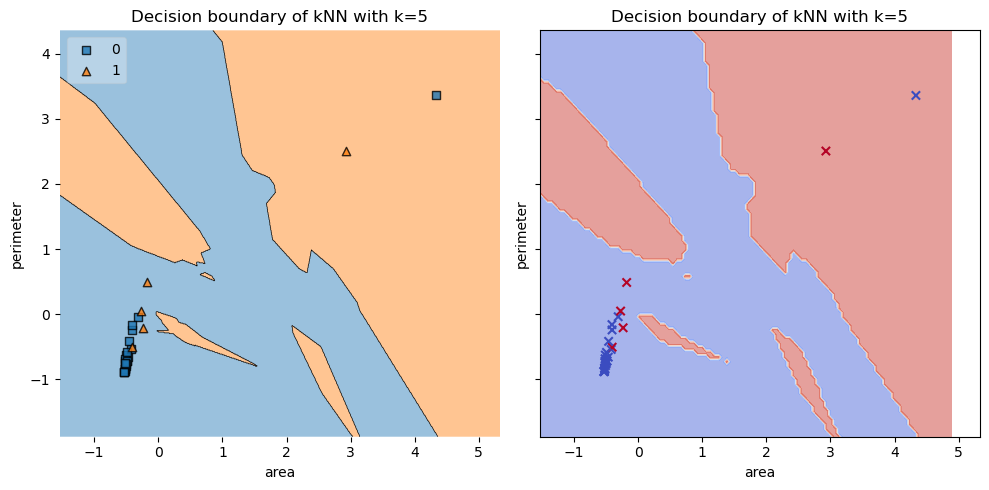

In [ ]:
# TODO YOUR CODE HERE
# Hint: try one value of k and read the link above to see how you can plot the decision boundary for that value.

## Variance of performance depending on the split

Notice the random state parameter of the splitting function. Why do we need this?

Pick two different values for the random split. For example a popular choice is 42.

For each of your values, split the data, and create the performance vs k-value plot (i.e. using the for loop you already created above). What do you notice and why?


QUESTIONS:

* What kind of strategies could you use to have less noisy plots?

* What does this tell you about the random_state, how is it different from for example a tunable k parameter?




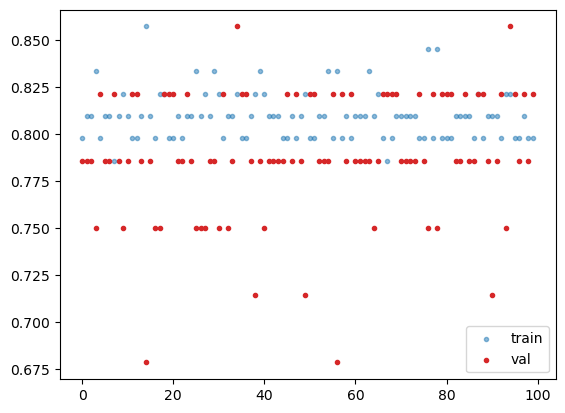

In [ ]:
# TODO YOUR CODE HERE
# Hint: generate a list of random seeds and loop through them to see how performance changes with different seeds. Make a plot of the performance as a function of the random seed.



## Cross-validation

In general in  your project you should use cross-validation on the development set to find good classifier parameters.

This example shows how the samples get split across the folds.

Question: what are other parameters of the KFold split and why might we need them?

In [9]:
from sklearn.model_selection import KFold

# Create the folds
kfold = KFold(n_splits=5, random_state=None, shuffle=False)
kfold.get_n_splits(dev_x, dev_y)

# Check the contents of the folds
for i, (train_index, dev_index) in enumerate(kfold.split(dev_x)):

    print(f"Fold {i}:")

    print(f"  Train: index={train_index}")

    print(f"  Test:  index={dev_index}")



Fold 0:
  Train: index=[ 23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40
  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111]
  Test:  index=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
Fold 1:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111]
  Test:  index=[23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]
Fold 2:
  Train: index=[  0   1   2   3   4   5   6   7   

## Other types of KFold

In many medical imaging applications instead of KFold we need to use GroupKFold or other options in the model_selection library.

**Question:**  

Why might we need to use GroupKFold? Does it apply to this example data you are using? And does it apply to the PAD-UFES data? Which variable creates the groups?



In [ ]:
 ## YOUR CODE HERE

## Combining everything and final evaluation

The examples above give you an idea of how you can investigate the quality of different classifiers and parameters.

Then once you have evaluated all the options, you can select some of the better ones, retrain them, now you can use the entire development set for retraining.

Your choice of these options needs to be reproducible in your project, i.e., you should not try out some classifiers/parameters and then completely remove them from your project.

You can evaluate the re-trained classifiers on the so far held-out test set. Your performances (how good each classifier was) might not reflect your results on the validation set.

You are NOT allowed to edit the classifiers after this point

[OPTIONAL] To keep track of the results (on the development set) of the options you try, instead of saving each result in a different variable you might want to make a "result dataset" where you track all the results. Each row is then a "run", and the columns are the different parameters and evaluation metrics. There are also different tools that allow doing this, for example MLFlow, but we do not cover it in the course.



In [ ]:
# TODO for students

# Keep track of different classifiers/parameters with an array

# Select some better ones (e.g. top 3)

# Re-train

# Evaluate on held-out set

# After this point you are not allowed to adjust the classifier, otherwise you are overfitting!